In [287]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

In [288]:
train_data = datasets.FashionMNIST(
        root="data", # the root folder to save the data
        train=True, # needed train data set
        download=True, # need to be downloaded
        transform=ToTensor(), # transform the datasets to tensors
        target_transform=None # not to transform the target at all
      )
test_data = datasets.FashionMNIST(
        root="data", # the root folder to save the data
        train=False, # testn data set needed instead of train
        download=True, # need to be downloaded
        transform=ToTensor(), # transform the datasets to tensors
        target_transform=None # not to transform the target at all
      )

In [289]:
# train_data.__len__(), test_data.__len__()

# train_data.classes, train_data.class_to_idx

# train_data.data.shape -> 60000 channels (28 width, 28 height)
# test_data.data.shape -> 1000 channels (28 width, 28 height)

# dir(train_data)
# train_data.train_labels
# list(train_data)
# train_data[6][0][:, 27]

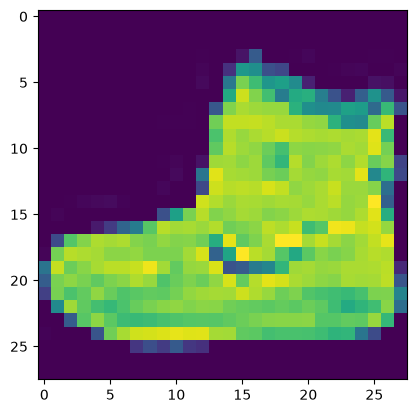

In [290]:
# Visualizing images

class_name = train_data.classes
img, label = train_data[0]
# print(img.squeeze().size())
# img.squeeze()
import matplotlib.pyplot as plt

plt.imshow(img.squeeze())


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

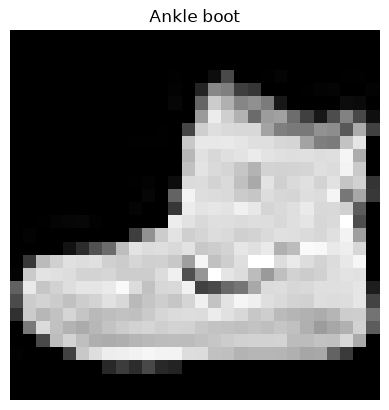

In [291]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_name[label])
plt.axis(False)

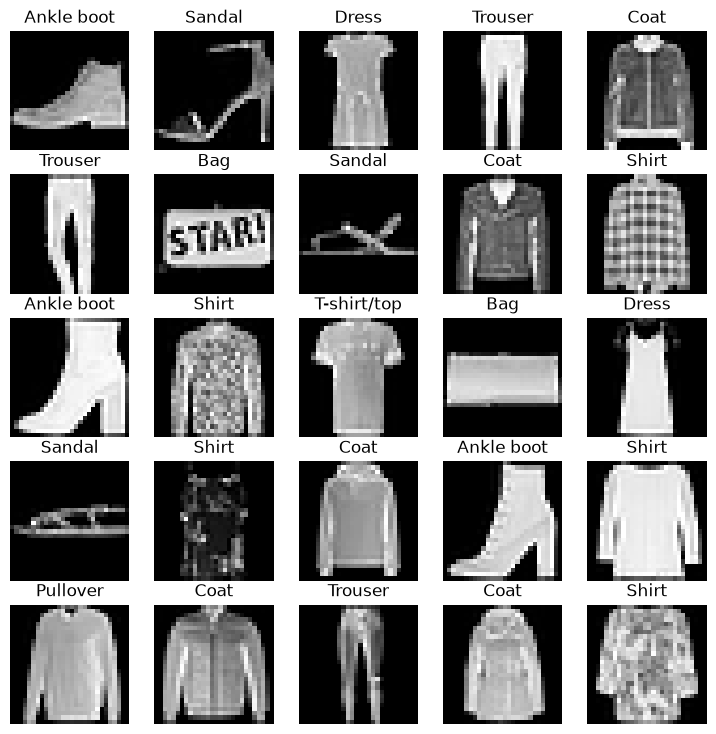

In [292]:
#  showing images randomly
torch.manual_seed(2026)
fig = plt.figure(figsize=(9,9))
rows, cols = 5, 5
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_name[label])
    plt.axis(False)

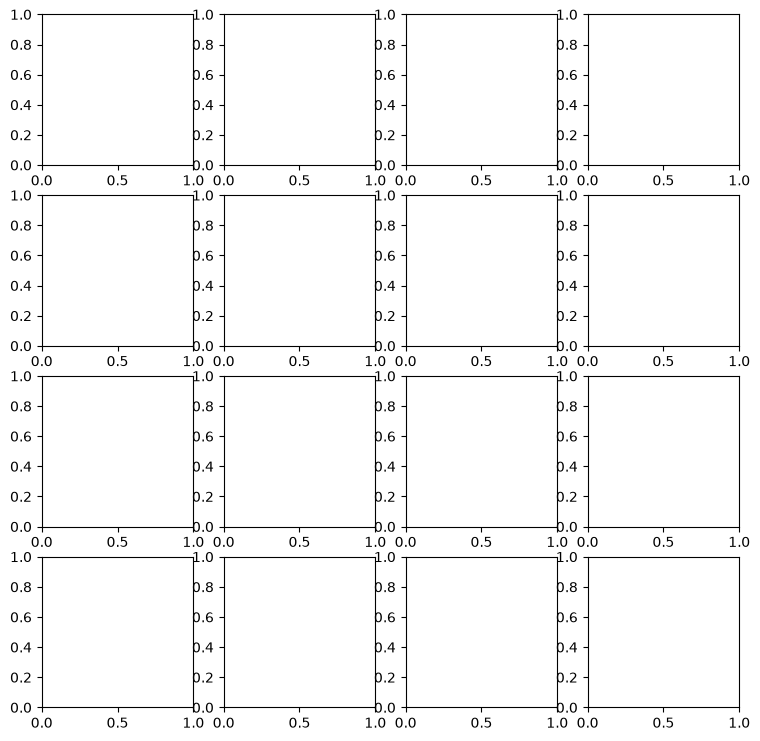

In [293]:
fig = plt.figure(figsize=(9,9))
for i in range(1,17):
    fig.add_subplot(4,4,i)
   


In [294]:
# - 2. Prepare DataLoader

# Right now, our data is in the form of PyTorch Datasets.
# DataLoader turns our dataset into a Python iterable.
# More specifically, we want to turn our data into batches (or mini-batches).
# Why would we do this?
# 1. It is more computationally efficient, as in, your computing hardware may not be able to look (store in memory) at 60000 images in one hit.
# So we break it down to 32 images at a time (batch size of 32).
# 2. It gives our neural network more chances to update its gradients per epoch.

# For more on mini-batches, see here: https://youtu.be/14ISUAcyHFs

# 3. Model 0: Build a basline model

# When starting to build a series of machine learning modelling experiments, it's best practice to start with a baseline model.
# A baseline model is a simple model you will try and improve upon with subsequent models/experiments.
# In other words: start simply and add complexity when necessary.

In [295]:
# torch.randn([1,1,28,28])

In [296]:
# array = [(5,7), (6,8)]



# # for tuple, (x, y) in enumerate(array):
# #     print(x, y)

# see = enumerate(array)
# list(see)

In [297]:
from tqdm import tqdm
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"train_dataloader: {len(train_dataloader)} of 32")
print(f"test_dataloader: {len(test_dataloader)} of 32")

train_features_batch, train_labels_batch = next(iter(train_dataloader))
test_features_batch, test_labels_batch = next(iter(test_dataloader))

train_features_batch.shape, train_labels_batch.shape, test_features_batch.shape, test_labels_batch.shape


train_dataloader: 1875 of 32
test_dataloader: 313 of 32


(torch.Size([32, 1, 28, 28]),
 torch.Size([32]),
 torch.Size([32, 1, 28, 28]),
 torch.Size([32]))

image size: torch.Size([1, 28, 28])
label size: torch.Size([])


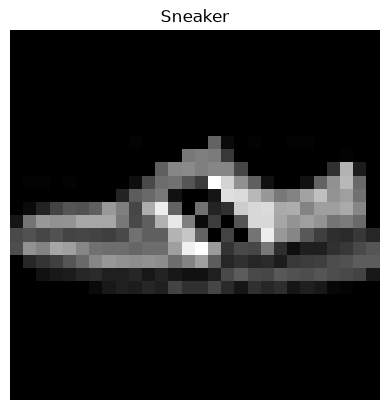

In [298]:
# torch.manual_seed(2026)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_name[label])
plt.axis("off")
print(f"image size: {img.shape}")
print(f"label size: {label.shape}")

In [299]:
# writing a model

flatten = nn.Flatten()
flatten(train_features_batch).shape

torch.Size([32, 784])

In [ ]:
from helper_function import accuracy_fn
from timeit import default_timer as timer

def print_time(start:float, end:float, device:torch.device = None):
    """
    Calculate the difference between the start time and end time...
    """
    total_time = end - start
    print(f"total time taken on {device}: {total_time:.3f} seconds")
    return

# model class

class FashionMNST(nn.Module):

    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.stack_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.stack_layers(x)


In [302]:
model = FashionMNST(input_features=(28*28), output_features=len(class_name))
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=model.parameters(), lr=0.1)


In [ ]:
# import tqdm for showing loading for epochs